In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder

In [2]:
import os
import zipfile

archive_path = r"C:\Users\AB\Downloads\sms+spam+collection.zip"

if not os.path.exists(archive_path):
    raise FileNotFoundError(f"Archive not found: {archive_path}")

extract_dir = os.path.join(os.path.dirname(archive_path), "extracted")
os.makedirs(extract_dir, exist_ok=True)

with zipfile.ZipFile(archive_path, "r") as z:
    z.extractall(extract_dir)

path = extract_dir
print(path)
print(os.listdir(path))

C:\Users\AB\Downloads\extracted
['readme', 'SMSSpamCollection']


In [3]:
import os
files = os.listdir(path)
print(files)

['readme', 'SMSSpamCollection']


In [23]:
data_file = next(file_name for file_name in files if file_name.lower() != "readme")

df = pd.read_csv(
    os.path.join(path, data_file),
    sep="\t",
    encoding="latin-1",
    header=None,
    names=["label", "message"]
)

df.head()

,label,message
0,ham,"Go until jurong point, crazy.. Available only ..."
1,ham,Ok lar... Joking wif u oni...
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...
3,ham,U dun say so early hor... U c already then say...
4,ham,"Nah I don't think he goes to usf, he lives aro..."


In [6]:
df.tail()

,label,message
5567,spam,This is the 2nd time we have tried 2 contact u...
5568,ham,Will Ã¼ b going to esplanade fr home?
5569,ham,"Pity, * was in mood for that. So...any other s..."
5570,ham,The guy did some bitching but I acted like i'd...
5571,ham,Rofl. Its true to its name


In [7]:
df.shape

(5572, 2)

In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5572 entries, 0 to 5571
Data columns (total 2 columns):
 #   Column   Non-Null Count  Dtype 
---  ------   --------------  ----- 
 0   label    5572 non-null   object
 1   message  5572 non-null   object
dtypes: object(2)
memory usage: 87.2+ KB


In [9]:
df.describe()

,label,message
count,5572,5572
unique,2,5169
top,ham,"Sorry, I'll call later"
freq,4825,30


In [10]:
df.columns

Index(['label', 'message'], dtype='object')

In [11]:
df.isnull().sum()

label      0
message    0
dtype: int64

In [12]:
df.duplicated().sum()

np.int64(403)

In [13]:
df.dtypes

label      object
message    object
dtype: object

In [24]:
le = LabelEncoder()

df["label"] = le.fit_transform(df["label"])


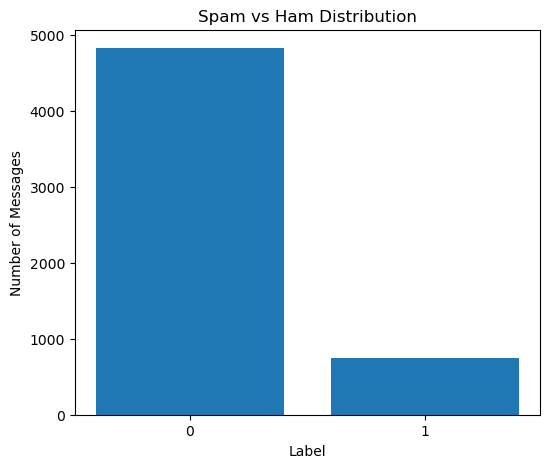

In [17]:
label_count = df["label"].value_counts()

plt.figure(figsize=(6,5))

plt.bar(label_count.index.astype(str), label_count.values)

plt.title("Spam vs Ham Distribution")
plt.xlabel("Label")
plt.ylabel("Number of Messages")

plt.show()

In [16]:
df.head()

,label,message
0,0,1094
1,0,3141
2,1,1012
3,0,4137
4,0,2796


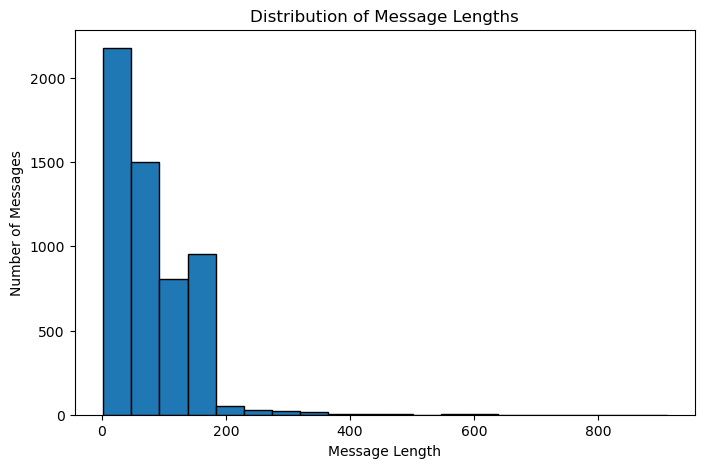

In [26]:
message_lengths = df["message"].astype(str).str.len()

plt.figure(figsize=(8,5))

plt.hist(message_lengths, bins=20, edgecolor='black')

plt.title("Distribution of Message Lengths")
plt.xlabel("Message Length")
plt.ylabel("Number of Messages")

plt.show()

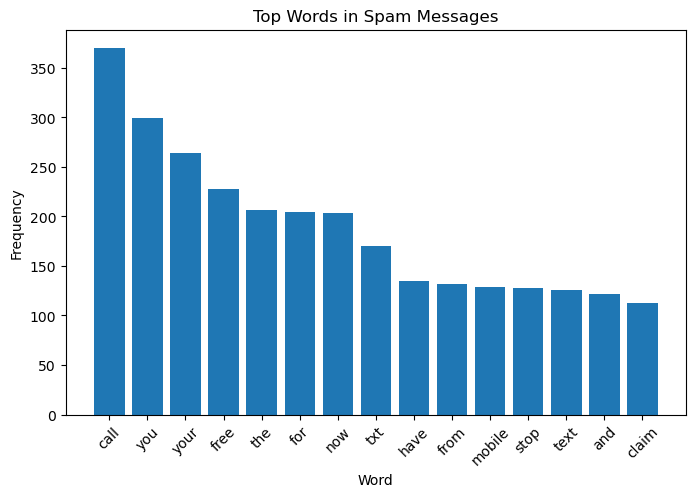

In [28]:
spam_label = le.transform(["spam"])[0]

spam_words = (
    df.loc[df["label"] == spam_label, "message"]
    .astype(str)
    .str.lower()
    .str.replace(r"[^a-z\s]", " ", regex=True)
    .str.split()
    .explode()
)

spam_words = spam_words[spam_words.str.len() > 2]
top_spam_words = spam_words.value_counts().head(15)

plt.figure(figsize=(8,5))

plt.bar(top_spam_words.index, top_spam_words.values)

plt.title("Top Words in Spam Messages")
plt.xlabel("Word")
plt.ylabel("Frequency")
plt.xticks(rotation=45)

plt.show()

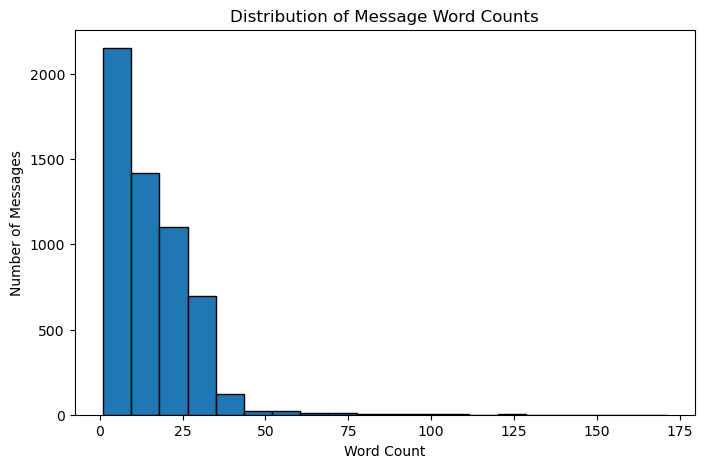

In [30]:
message_word_counts = df["message"].astype(str).str.split().str.len()

plt.figure(figsize=(8,5))

plt.hist(message_word_counts, bins=20, edgecolor="black")

plt.title("Distribution of Message Word Counts")
plt.xlabel("Word Count")
plt.ylabel("Number of Messages")

plt.show()

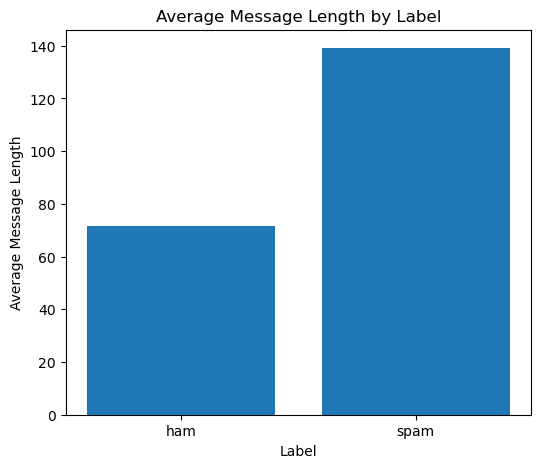

In [32]:
avg_message_length = df.assign(
    message_length=df["message"].astype(str).str.len()
).groupby("label")["message_length"].mean()

label_names = le.inverse_transform(avg_message_length.index.astype(int))

plt.figure(figsize=(6,5))

plt.bar(label_names, avg_message_length.values)

plt.title("Average Message Length by Label")
plt.xlabel("Label")
plt.ylabel("Average Message Length")

plt.show()

In [35]:
print("Average Message Length:", df["message"].astype(str).str.len().mean())

Average Message Length: 80.61629576453697


In [36]:
print("Longest Message Length:", df["message"].astype(str).str.len().max())

Longest Message Length: 910


In [37]:
print("Shortest Message Length:", df["message"].astype(str).str.len().min())

Shortest Message Length: 2


In [38]:
df["At_Risk"] = df["label"]

In [40]:
X = df.assign(message_length=df["message"].astype(str).str.len())[["message_length"]]
y = df["At_Risk"]

In [41]:
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)

model = DecisionTreeClassifier(random_state=42)
model.fit(X_train, y_train)

DecisionTreeClassifier(random_state=42)

In [42]:
importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": model.feature_importances_
})

importance = importance.sort_values(by="Importance", ascending=False)

importance

,Feature,Importance
0,message_length,1.0


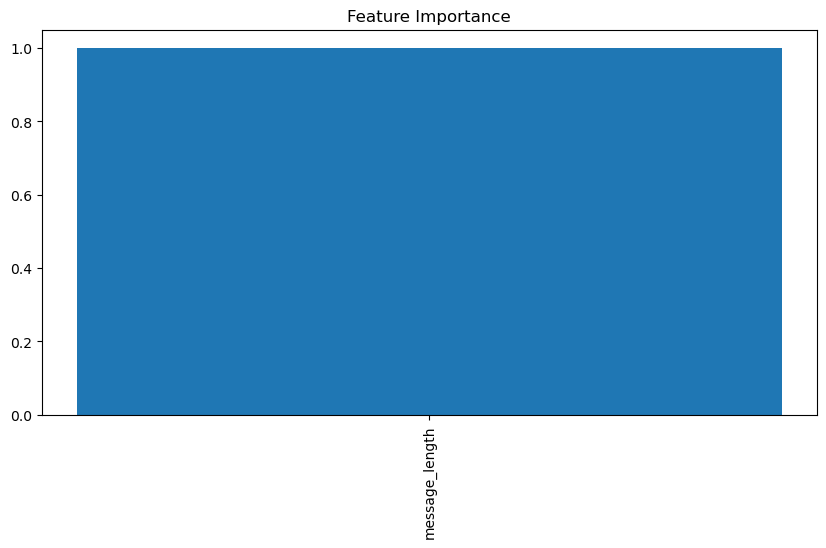

In [43]:
plt.figure(figsize=(10,5))

plt.bar(importance["Feature"], importance["Importance"])

plt.xticks(rotation=90)
plt.title("Feature Importance")

plt.show()

In [45]:
corr = df.select_dtypes(include=np.number).corr()
corr

,label,At_Risk
label,1.0,1.0
At_Risk,1.0,1.0


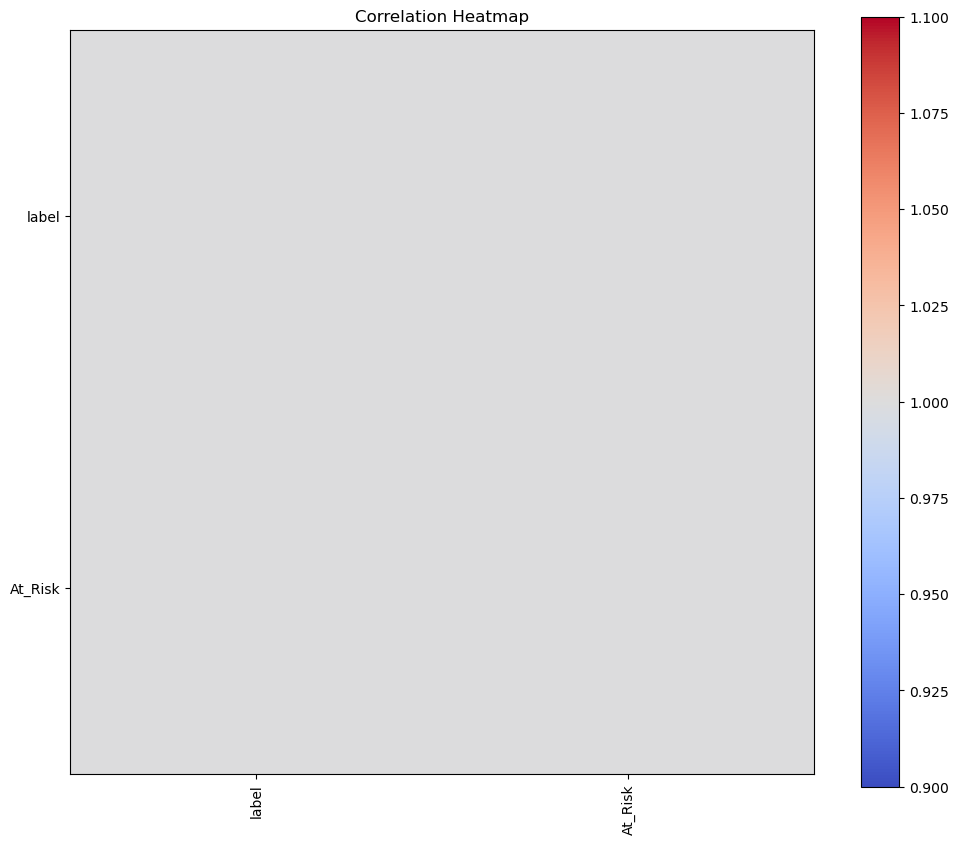

In [46]:
plt.figure(figsize=(12,10))
plt.imshow(corr, cmap="coolwarm")
plt.colorbar()
plt.xticks(range(len(corr.columns)), corr.columns, rotation=90)
plt.yticks(range(len(corr.columns)), corr.columns)
plt.title("Correlation Heatmap")
plt.show()

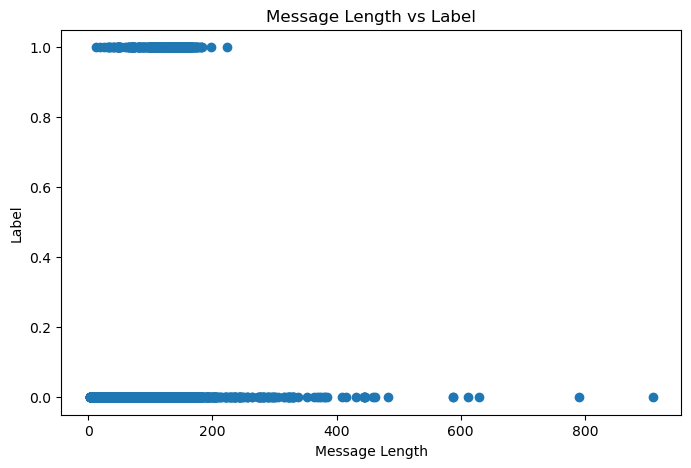

In [48]:
plt.figure(figsize=(8,5))

plt.scatter(df["message"].astype(str).str.len(), df["label"])

plt.title("Message Length vs Label")
plt.xlabel("Message Length")
plt.ylabel("Label")
plt.show()

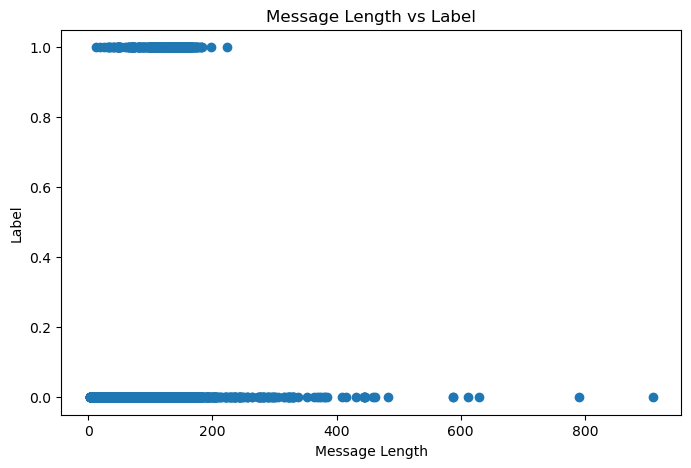

In [49]:
plt.figure(figsize=(8,5))

plt.scatter(df["message"].astype(str).str.len(), df["label"])

plt.title("Message Length vs Label")
plt.xlabel("Message Length")
plt.ylabel("Label")
plt.show()

In [50]:
df["label"].value_counts()

label
0    4825
1     747
Name: count, dtype: int64

In [ ]:
df.groupby("Tutoring")["GPA"].mean()

,GPA
Tutoring,
0,1.818968
1,2.108325


In [ ]:
df.groupby("Sports")["GPA"].mean()

,GPA
Sports,
0,1.871240
1,1.986381
